In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../../DATA/Telco-Customer-Churn.csv')

In [8]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Анализ распределения признаков относительно признака Churn

<Axes: xlabel='Churn', ylabel='count'>

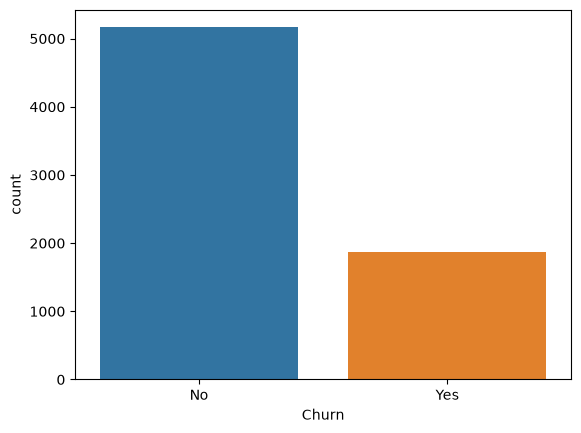

In [19]:
sns.countplot(data=df, x="Churn", hue="Churn")

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

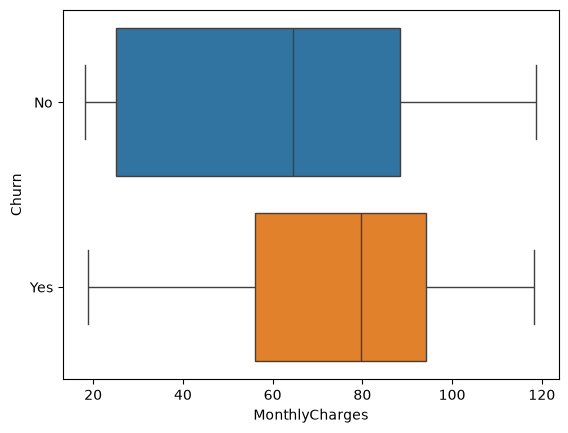

In [24]:
sns.boxplot(data=df, x= "MonthlyCharges", y="Churn", hue="Churn")

График сверху может показаться странным, но скорее всего это связяно с тем, что остаются те люд, что покупают годовые подписки, а они обычно дешевле в пересчете на один месяц

<Axes: xlabel='TotalCharges', ylabel='Churn'>

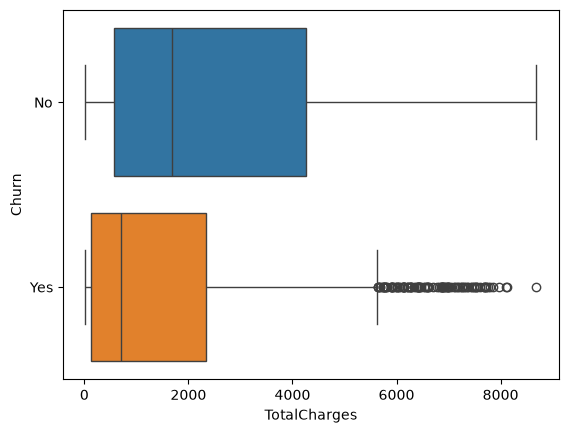

In [26]:
sns.boxplot(data=df, x="TotalCharges", y="Churn", hue="Churn")

<Axes: xlabel='tenure', ylabel='Churn'>

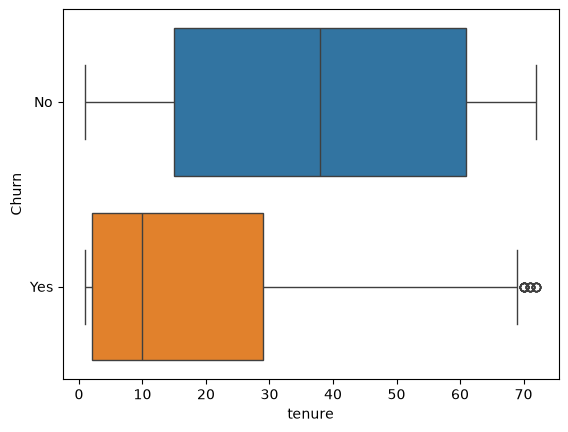

In [28]:
sns.boxplot(data=df, x= "tenure", y="Churn", hue="Churn")

<Axes: xlabel='Contract', ylabel='count'>

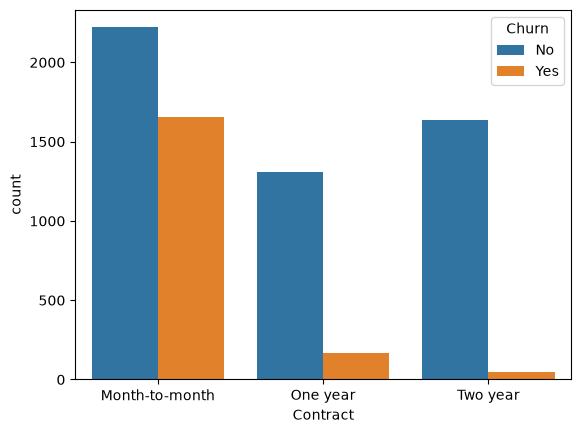

In [93]:
sns.countplot(data=df, x="Contract", hue="Churn")

Явно видно, что среди оттока редко совершаются подписки годовые и двух годовые(бквально 2 раза в сумме)

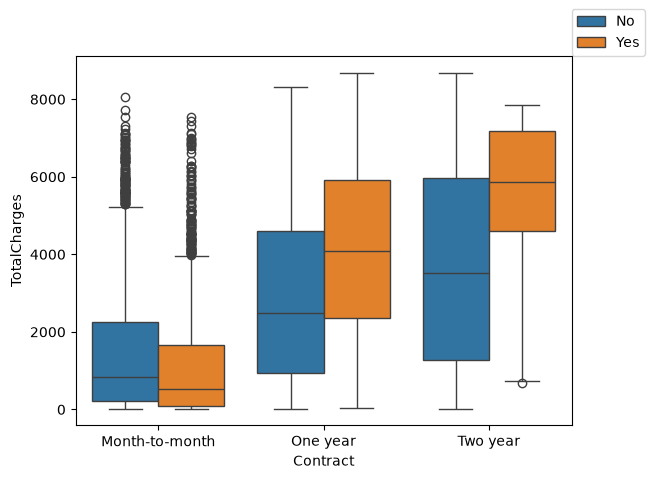

In [34]:
sns.boxplot(data=df, y="TotalCharges", x="Contract", hue="Churn")
plt.legend(loc=[1, 1])

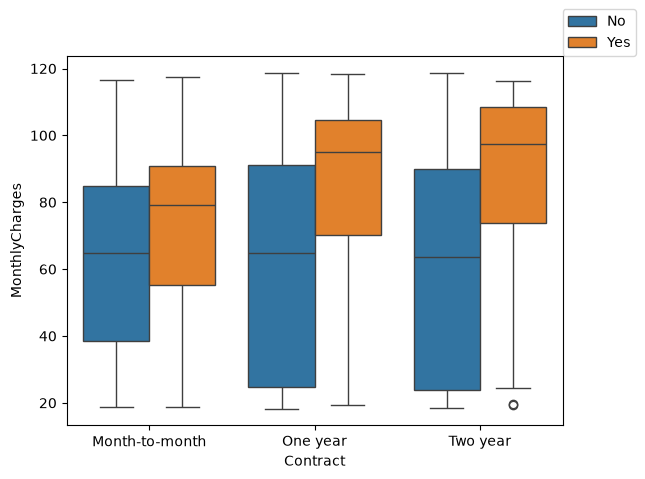

In [35]:
sns.boxplot(data=df, y="MonthlyCharges", x="Contract", hue="Churn")
plt.legend(loc=[1, 1])

Тут подтверждается моя первая гипотеза, отток характерен для тех кто много тратит в месяц, но меньше в общей сумме, что как я думаю связано с распределением цен в тарифных планах

Так же заметно, что в оттоке имеются люди с подписками на год и на два и их суммарные затраты выше среднего в этой категории, надо подробнее рассмотреть этот момент

In [40]:
df_abnormal = df[(df["Churn"] == "Yes") & ((df["Contract"] == "One year") | (df["Contract"] == "Two year"))]

In [55]:
print(df_abnormal["gender"].value_counts())
print(df["gender"].value_counts())
print()

print(df_abnormal["SeniorCitizen"].value_counts())
print(df["SeniorCitizen"].value_counts())
print()

print(df_abnormal["Partner"].value_counts())
print(df["Partner"].value_counts())
print()

print(df_abnormal["Dependents"].value_counts())
print(df["Dependents"].value_counts())
print()

print(df_abnormal["PaymentMethod"].value_counts())
print(df["PaymentMethod"].value_counts())
print()

print(df_abnormal["StreamingTV"].value_counts())
print(df["StreamingTV"].value_counts())
print()

print(df_abnormal["StreamingMovies"].value_counts())
print(df["StreamingMovies"].value_counts())
print()

gender
Male      117
Female     97
Name: count, dtype: int64
gender
Male      3549
Female    3483
Name: count, dtype: int64

SeniorCitizen
0    179
1     35
Name: count, dtype: int64
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Partner
Yes    129
No      85
Name: count, dtype: int64
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents
No     147
Yes     67
Name: count, dtype: int64
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PaymentMethod
Electronic check             77
Bank transfer (automatic)    57
Credit card (automatic)      54
Mailed check                 26
Name: count, dtype: int64
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

StreamingTV
Yes                    157
No                      43
No internet service     14
Name: count, dtype: int64
StreamingTV
No                     2809
Yes             

На глаз видна заметная разница в стриминге(его распределение) относительно исходного

# Корреляционный анализ

In [80]:
corr_df  = pd.concat([
    df["TotalCharges"],
    pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod','Churn']])], axis=1).corr()

In [81]:
corr_df_churn = corr_df["Churn_Yes"].sort_values().drop(["Churn_No", "Churn_Yes"])

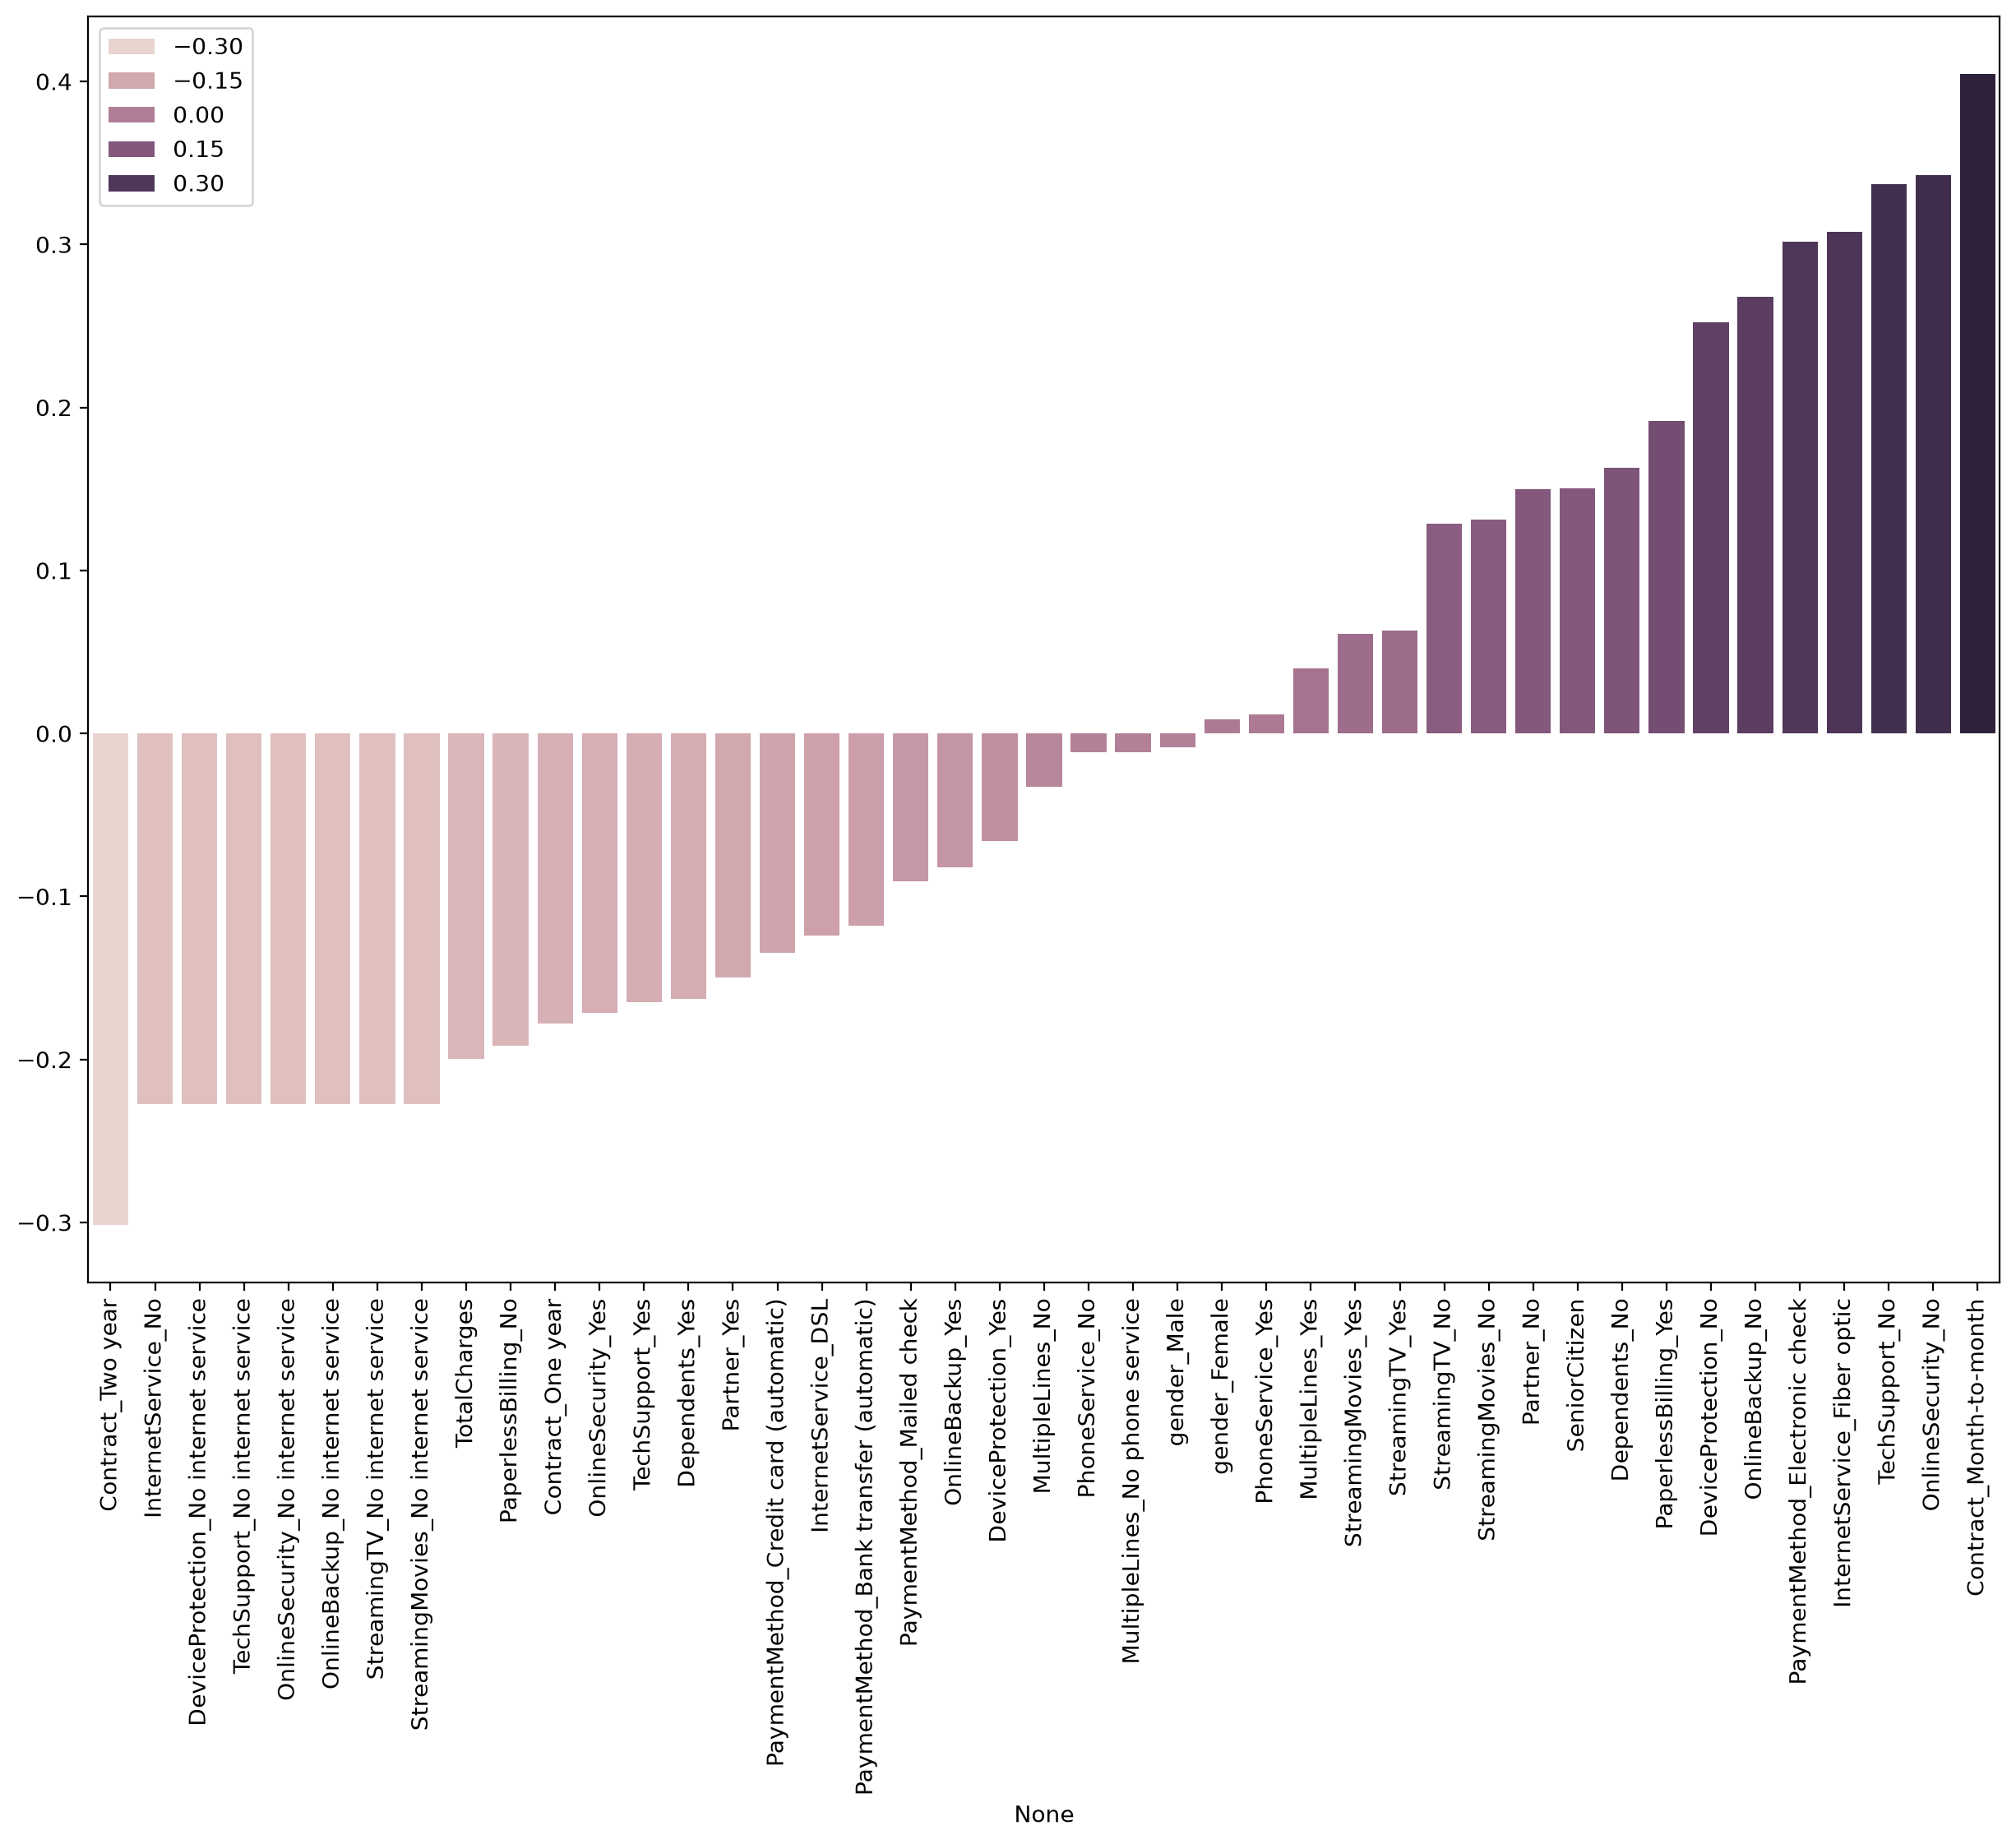

In [82]:
plt.figure(figsize=(15,10), dpi=200)
sns.barplot(x=corr_df_churn.index, y=corr_df_churn.values, hue=corr_df_churn.values)
plt.xticks(rotation=90);

Видно из графика что отток сильно зависит от месячной подписки, отсутвия услуги поддержки и отсутсвия онлайн защиты(и подобное), также тип оплаты коррелирует(а именно когда самостоятельно проверяют и оплачивают, что тоже логично)

In [83]:
corr_df_charg = corr_df["TotalCharges"].sort_values().drop(["TotalCharges"])

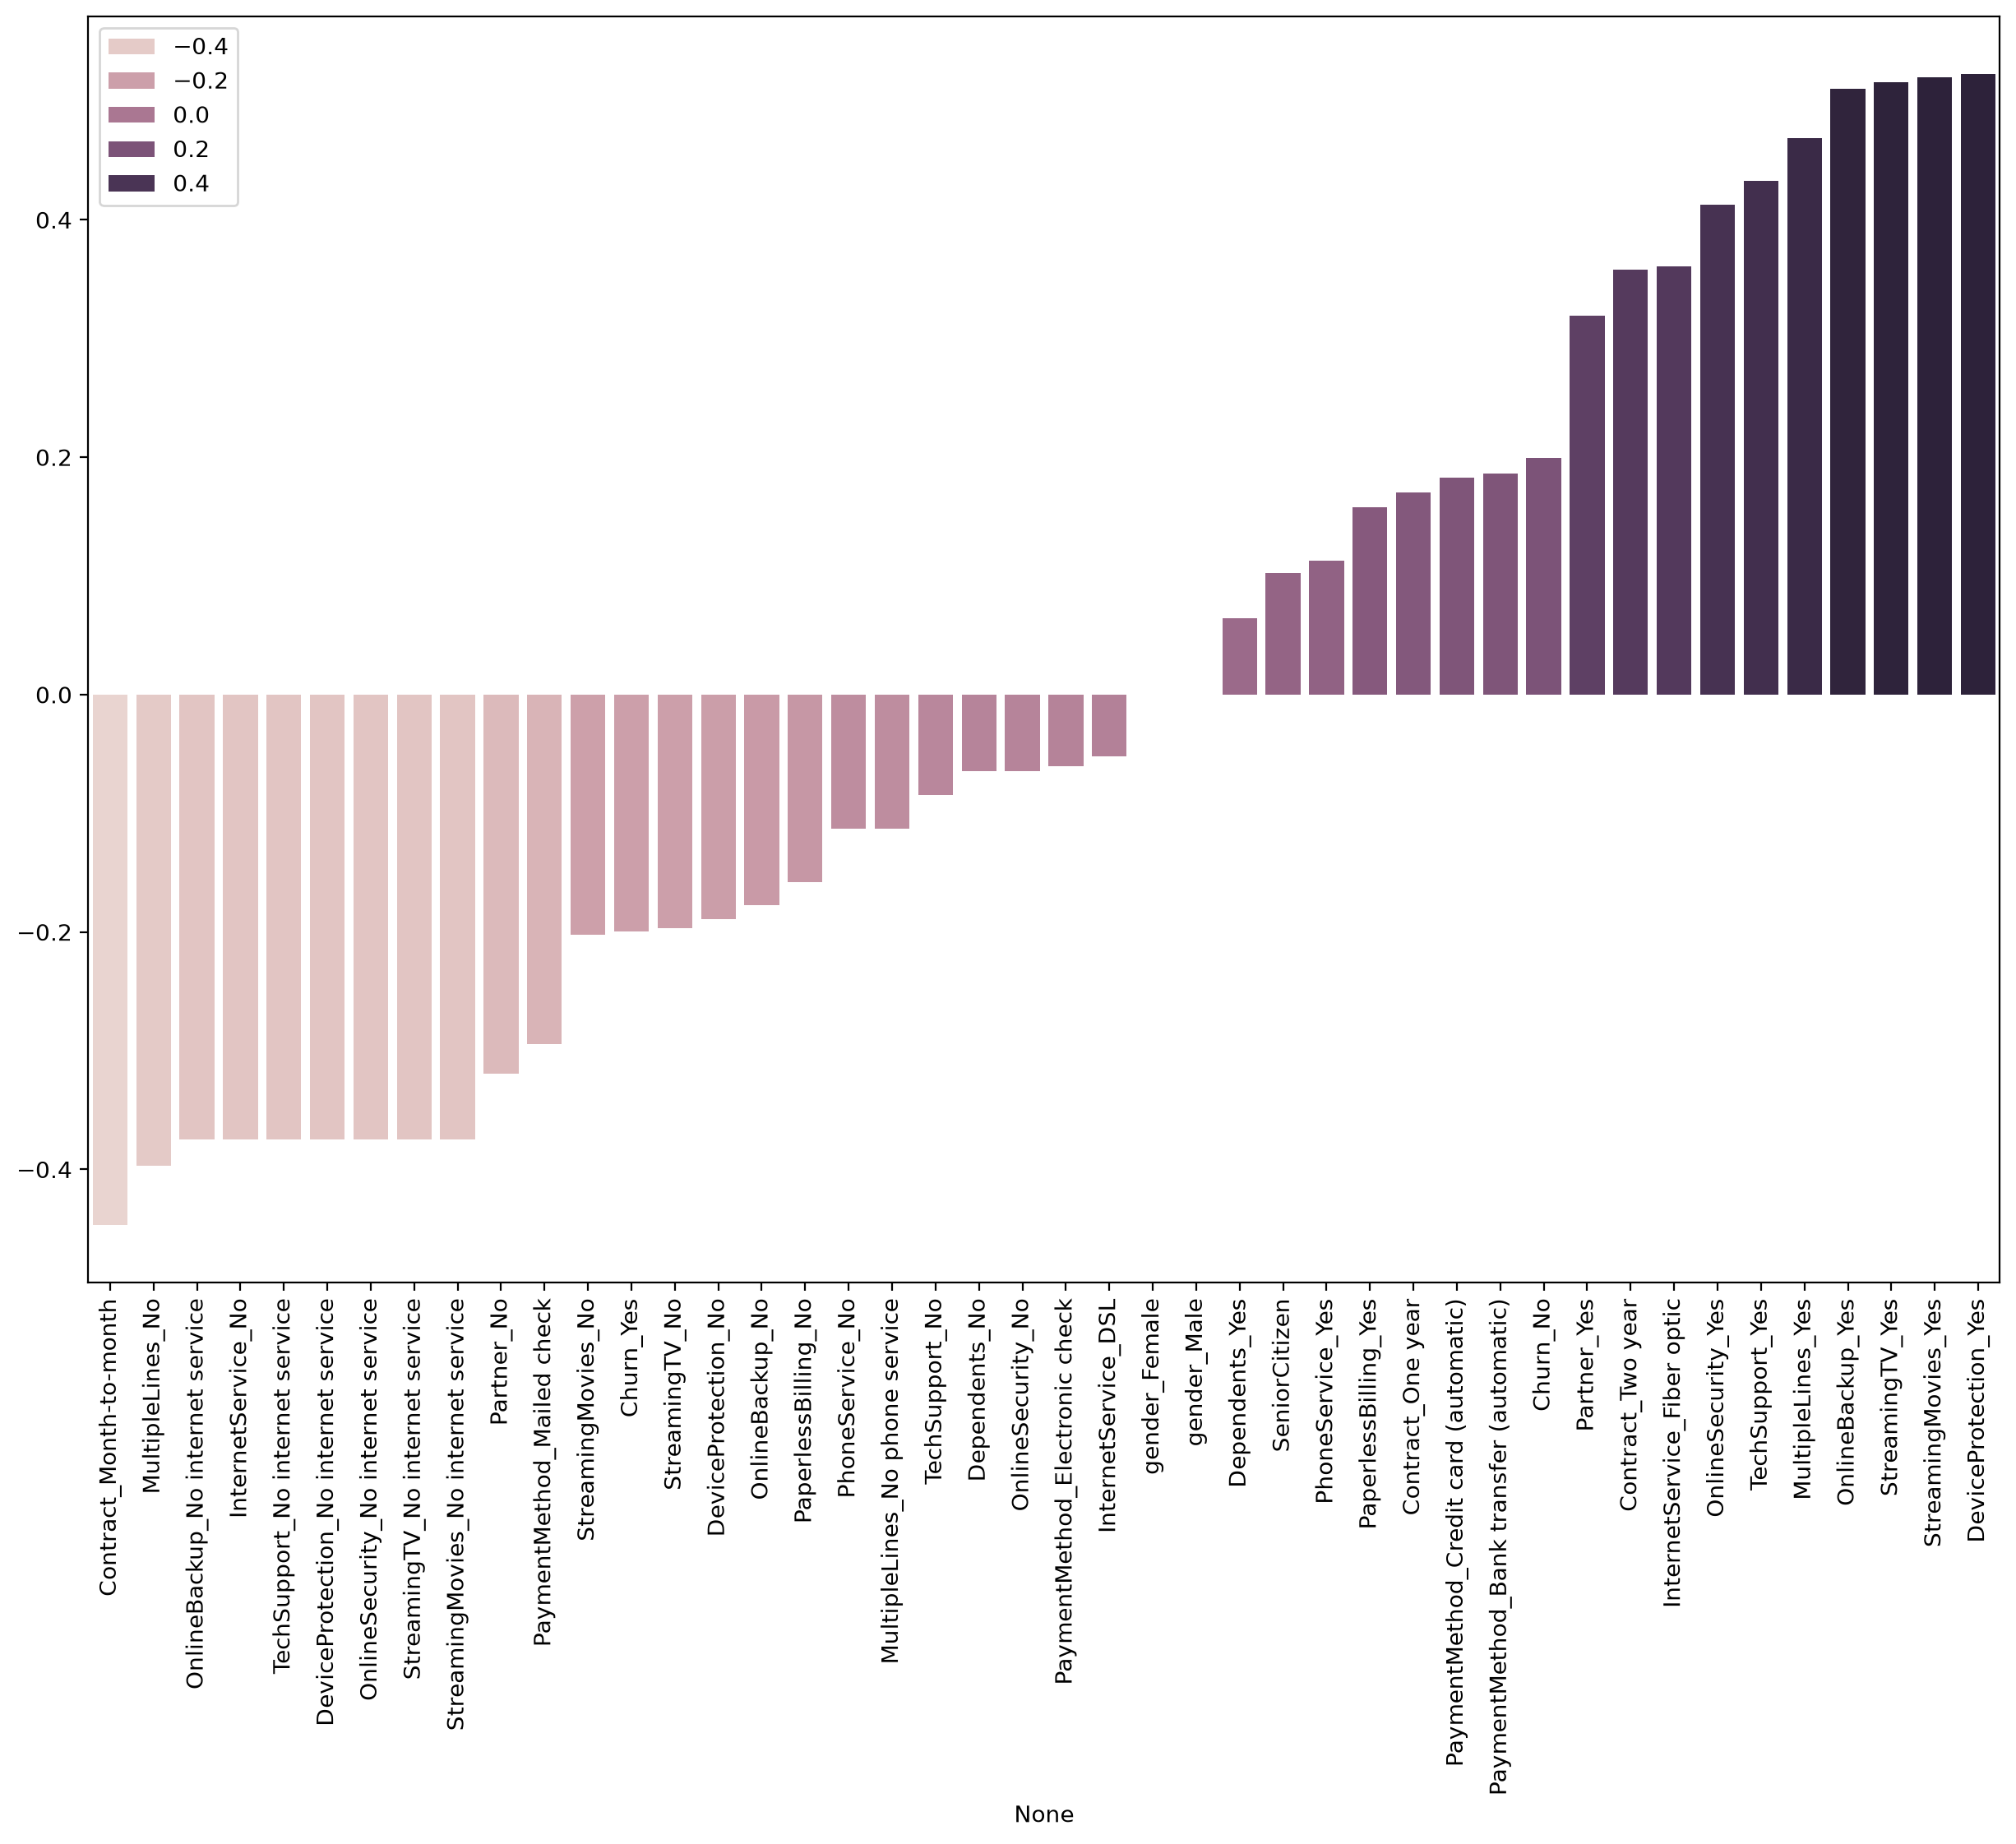

In [87]:
plt.figure(figsize=(15,10), dpi=200)
sns.barplot(x=corr_df_charg.index, y=corr_df_charg.values, hue=corr_df_charg.values)
plt.xticks(rotation=90);

Как я отмечал ранее - высокая корреляция с стримингом

# Анализ распределений признаков

<Axes: xlabel='Contract', ylabel='count'>

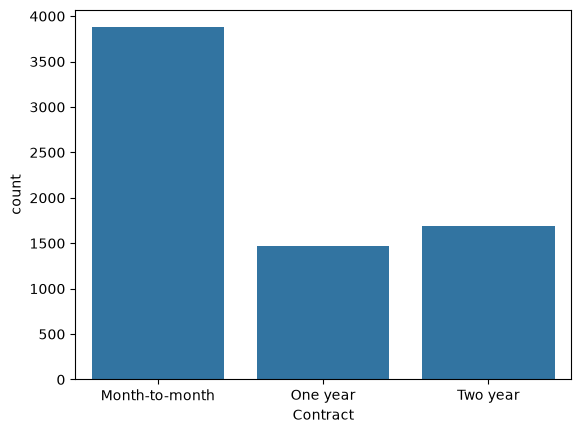

In [88]:
sns.countplot(data=df, x="Contract")

<Axes: xlabel='TotalCharges', ylabel='Count'>

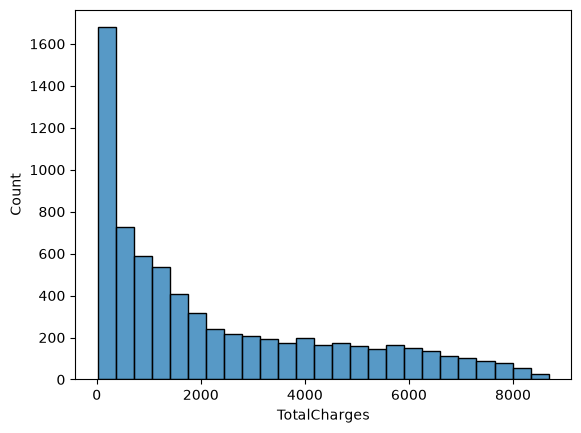

In [89]:
sns.histplot(data=df, x="TotalCharges")

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

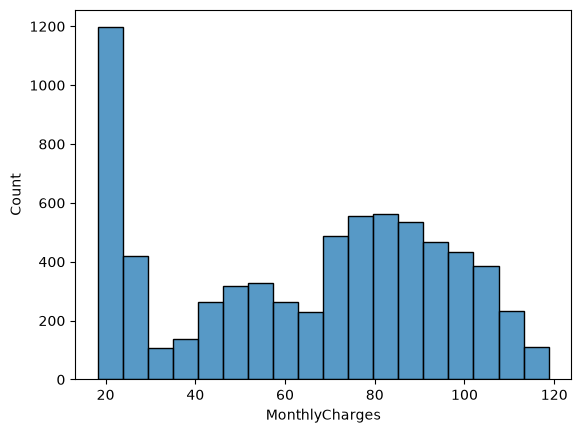

In [90]:
sns.histplot(data=df, x="MonthlyCharges")

<Axes: xlabel='tenure', ylabel='Count'>

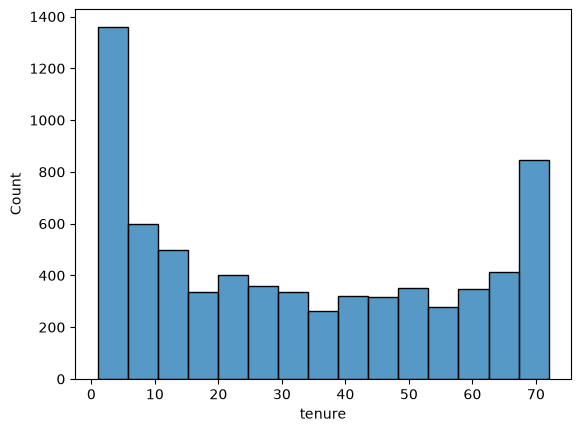

In [91]:
sns.histplot(data=df, x="tenure")

много новых польхователей и много очень старых пользователей